In [ ]:
# 📦 Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
# ⚙️ Paths
genuine_path = 'signatures/Genuine'
forgery_path = 'signatures/Forged'

In [ ]:
# 📐 Image Settings
IMG_SIZE = (224, 224)

def load_and_preprocess_image(path):
    img = load_img(path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    return preprocess_input(img_array)


In [ ]:
# 📥 Load Dataset
X, y = [], []

for filename in os.listdir(genuine_path):
    if filename.endswith('.png'):
        X.append(load_and_preprocess_image(os.path.join(genuine_path, filename)))
        y.append(1)

for filename in os.listdir(forgery_path):
    if filename.endswith('.png'):
        X.append(load_and_preprocess_image(os.path.join(forgery_path, filename)))
        y.append(0)

X = np.array(X)
y = np.array(y)
print(f"✅ Loaded {len(X)} images.")


✅ Loaded 2640 images.


In [ ]:

# 🔀 Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 🧠 Build Model
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:

# 🚀 Train Model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=8)

Epoch 1/10


C:\Users\Tharu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(8, 224, 224, 3))
  warnings.warn(msg)


264/264 ━━━━━━━━━━━━━━━━━━━━ 995s 4s/step - accuracy: 0.7806 - loss: 0.4852 - val_accuracy: 0.9773 - val_loss: 0.1132
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.9720 - loss: 0.1072 - val_accuracy: 0.9848 - val_loss: 0.0577
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 461s 2s/step - accuracy: 0.9839 - loss: 0.0645 - val_accuracy: 0.9962 - val_loss: 0.0374
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.9974 - loss: 0.0348 - val_accuracy: 0.9981 - val_loss: 0.0248
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - accuracy: 0.9985 - loss: 0.0257 - val_accuracy: 0.9981 - val_loss: 0.0192
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.9999 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.9995 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 0.0112
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 1.0000 - loss: 0.0137 - val_accuracy: 1.000

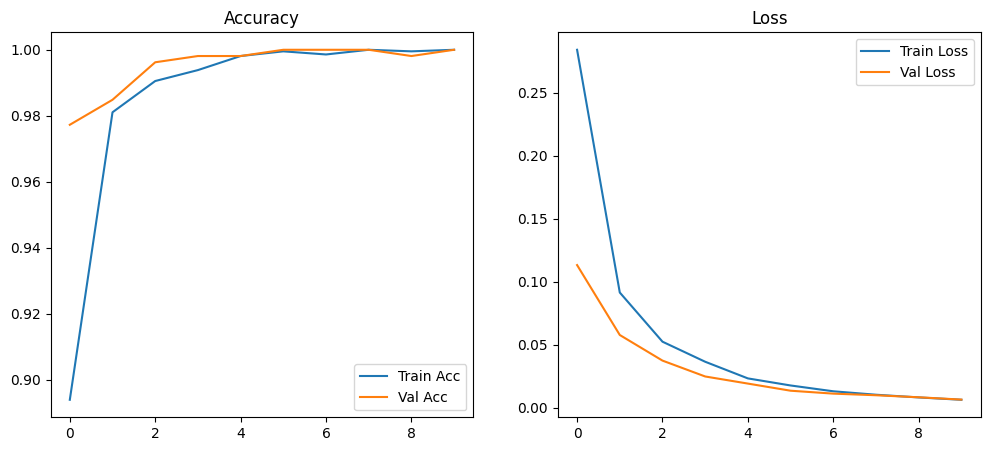

In [ ]:
# 📊 Plot Training Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# 📈 Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"🎯 Test Accuracy: {acc*100:.2f}%")

C:\Users\Tharu\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


🎯 Test Accuracy: 100.00%


In [ ]:
# 💾 Save Model
model.save("signature_model.h5")
print("✅ Model saved as 'signature_model.h5'")

✅ Model saved as 'signature_model.h5'


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


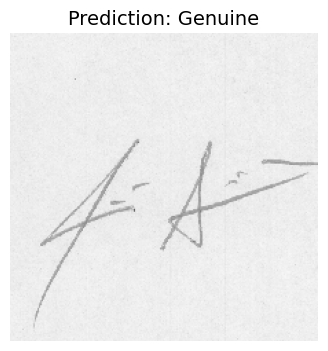

🧪 Prediction on test image: Genuine


In [ ]:
# 🧪 Function to Test New Image
# 🧪 Function to Test New Image and Display
def predict_and_show_signature(image_path):
    img = load_and_preprocess_image(image_path)
    img_expanded = np.expand_dims(img, axis=0)
    prediction = model.predict(img_expanded)[0][0]
    result = "Genuine" if prediction >= 0.5 else "Forged"

    # Display the image with prediction
    plt.figure(figsize=(4, 4))
    original_img = load_img(image_path, target_size=IMG_SIZE)
    plt.imshow(original_img)
    plt.title(f"Prediction: {result}", fontsize=14)
    plt.axis('off')
    plt.show()

    return result

# ✨ Test Example
test_path = r"C:\Users\Tharu\Desktop\sign_detector\signatures\Genuine\original_1_24.png"
result = predict_and_show_signature(test_path)
print(f"🧪 Prediction on test image: {result}")



